# 01 — Data Check
**Part A | Milestone 1**

Goal: confirm the raw EuRoC data loads correctly, look at what the raw
signals actually look like, and compare the three sequences before doing
anything else with them.

Run `python scripts/verify_data.py` from the terminal first — this notebook
assumes that already passed.

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import yaml
import numpy as np
import matplotlib.pyplot as plt

from vio_drift.data.loader import load_sequence
from vio_drift.data.align import report_gaps

config = yaml.safe_load((Path.cwd().parent / "configs" / "config.yaml").read_text())
raw_dir = Path.cwd().parent / config["data"]["raw_dir"]
sequences = config["data"]["sequences"]
sequences

['MH_01_easy', 'MH_02_easy', 'MH_03_medium']

## Load all three sequences

We load IMU + ground truth for each sequence and print how many rows we
got and the implied sampling rate — this should be close to 200 Hz for
IMU on every sequence.

In [4]:
loaded = {}
for seq_name in sequences:
    imu_df, gt_df = load_sequence(raw_dir, seq_name)
    loaded[seq_name] = (imu_df, gt_df)
    gaps = report_gaps(imu_df, gt_df)
    print(f"{seq_name}: {len(imu_df)} IMU rows, {len(gt_df)} GT rows")
    print(f"   IMU rate ~{gaps['imu']['implied_rate_hz']:.1f} Hz, "
          f"GT rate ~{gaps['ground_truth']['implied_rate_hz']:.1f} Hz")
    print(f"   duration ~{gaps['imu']['duration_s']:.1f} s\n")

MH_01_easy: 36820 IMU rows, 36382 GT rows
   IMU rate ~200.0 Hz, GT rate ~200.0 Hz
   duration ~184.1 s

MH_02_easy: 30400 IMU rows, 29993 GT rows
   IMU rate ~200.0 Hz, GT rate ~200.0 Hz
   duration ~152.0 s

MH_03_medium: 27008 IMU rows, 26302 GT rows
   IMU rate ~200.0 Hz, GT rate ~200.0 Hz
   duration ~135.0 s



## Raw IMU signals — one sequence

Plot gyro and accel for the first sequence, first 10 seconds, so we can
see what "normal" motion looks like before checking the others.

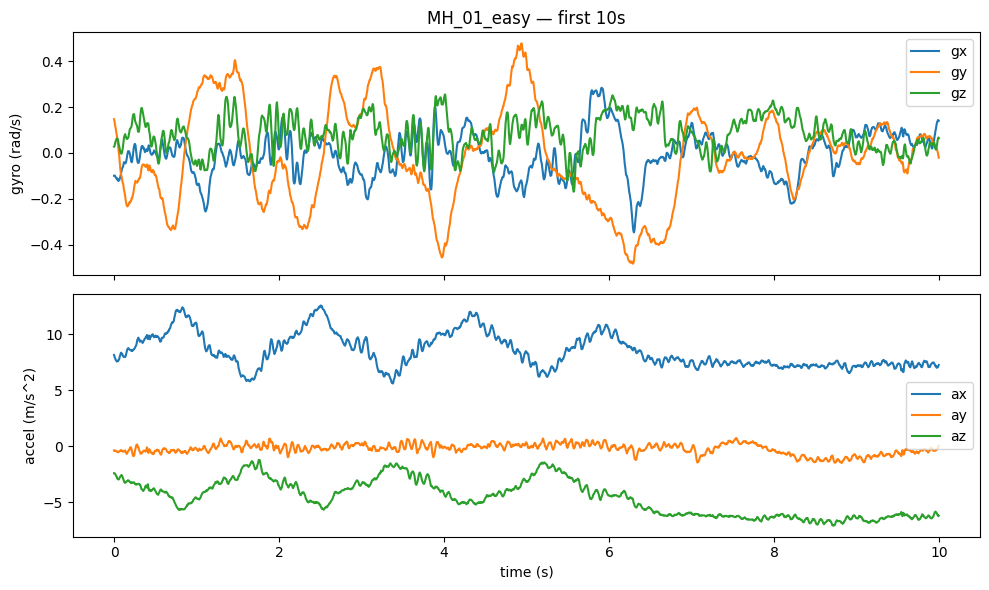

In [5]:
seq_name = sequences[0]
imu_df, gt_df = loaded[seq_name]

t = (imu_df["t_ns"] - imu_df["t_ns"].iloc[0]) / 1e9
mask = t < 10  # first 10 seconds

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for col in ["gx", "gy", "gz"]:
    axes[0].plot(t[mask], imu_df.loc[mask, col], label=col)
axes[0].set_ylabel("gyro (rad/s)")
axes[0].legend()
axes[0].set_title(f"{seq_name} — first 10s")

for col in ["ax", "ay", "az"]:
    axes[1].plot(t[mask], imu_df.loc[mask, col], label=col)
axes[1].set_ylabel("accel (m/s^2)")
axes[1].set_xlabel("time (s)")
axes[1].legend()

plt.tight_layout()
plt.savefig(Path.cwd().parent / "figures" / "eda" / "raw_imu_signals.png", dpi=150)
plt.show()

**Sanity check:** `az` should sit close to +9.81 (or -9.81, depending on
axis convention) when the drone is roughly level and stationary/slow —
that's the accelerometer sensing gravity. If it's near 0 instead, something
is off in how the file was read.

## True 3D trajectory — all three sequences

Compare the flight paths. MH_03 (medium difficulty) should look like a
longer or more aggressive path than the two "easy" ones.

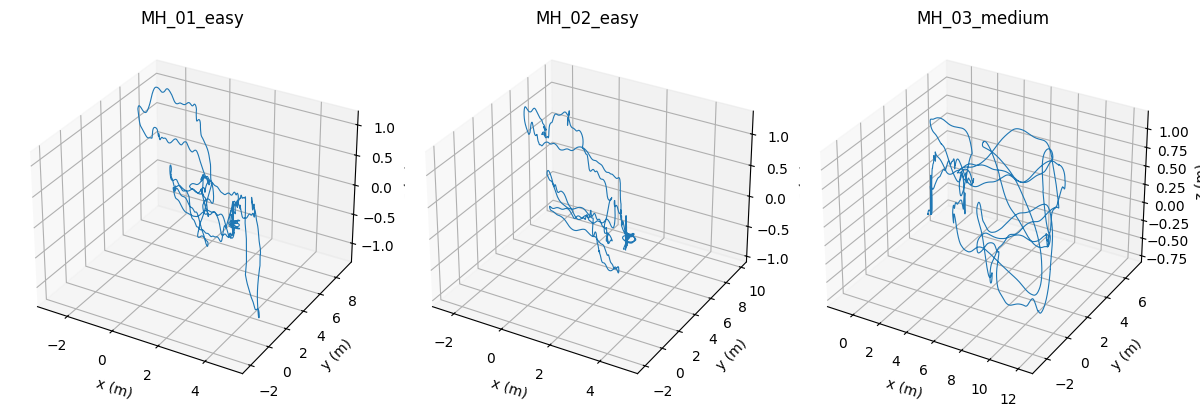

In [6]:
fig = plt.figure(figsize=(12, 4))
for i, seq_name in enumerate(sequences):
    _, gt_df = loaded[seq_name]
    ax = fig.add_subplot(1, 3, i + 1, projection="3d")
    ax.plot(gt_df["px"], gt_df["py"], gt_df["pz"], linewidth=0.8)
    ax.set_title(seq_name)
    ax.set_xlabel("x (m)"); ax.set_ylabel("y (m)"); ax.set_zlabel("z (m)")

plt.tight_layout()
plt.savefig(Path.cwd().parent / "figures" / "eda" / "true_trajectories.png", dpi=150)
plt.show()

## Speed over time — all three sequences

Derived from consecutive ground-truth positions. Higher/more variable
speed in MH_03 would explain why it's labeled "medium" difficulty.

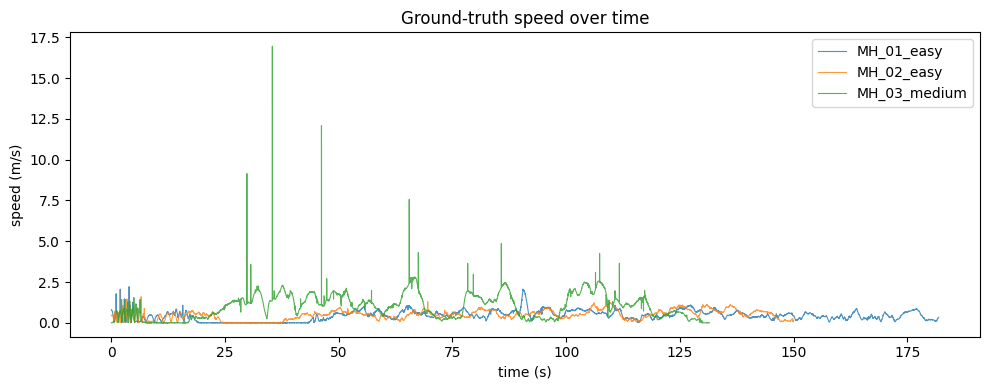

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
for seq_name in sequences:
    _, gt_df = loaded[seq_name]
    t = (gt_df["t_ns"] - gt_df["t_ns"].iloc[0]) / 1e9
    dp = gt_df[["px", "py", "pz"]].diff()
    dt = gt_df["t_ns"].diff() / 1e9
    speed = np.sqrt((dp["px"]**2 + dp["py"]**2 + dp["pz"]**2)) / dt
    ax.plot(t, speed, label=seq_name, alpha=0.8, linewidth=0.8)

ax.set_xlabel("time (s)")
ax.set_ylabel("speed (m/s)")
ax.legend()
ax.set_title("Ground-truth speed over time")
plt.tight_layout()
plt.savefig(Path.cwd().parent / "figures" / "eda" / "speed_comparison.png", dpi=150)
plt.show()

## What we learned (fill this in after running)

- IMU rate confirmed at ~___ Hz across all sequences.
- Any missing values or large timestamp gaps found: ___
- MH_03_medium differs from MH_01/02 in: ___
- Anything unexpected in the raw signals: ___
